# Bias 2024


In [1]:
%matplotlib widget
%load_ext autoreload
%autoreload 2

In [2]:
import xarray as xr
import numpy as np
import xroms # needed to do cf things
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import cmocean.cm as cmo
#from utils import get_boundary_slice, plot_2boundary_slice
plt.rcParams['figure.figsize'] = [12, 8]
plt.rcParams['font.size'] = 18

## Open the month-averaged data (which has already been processed by xroms to get z-depth data)

The month-averaged files are much smaller to work with than the day-averaged files

Note: see the files daily_mean.sh and add_time_dim.sh on how these averaged files were obtained (using ncwa ncrcat). Also see get_monthly_zdepth.py for the xroms conversion

In [ ]:
dir_avr='https://thredds.met.no/thredds/dodsC/foccus/' #norshelf-ana_fwd_avr_20240*_outer*.nc
file0 = 'norshelf-ana_fwd_avr_zdepth_202401-12_outer0.nc'
file1 = 'norshelf-ana_fwd_avr_zdepth_202401-12_outer1.nc'
ds0 = xr.open_dataset(dir_avr+file0)
ds1 = xr.open_dataset(dir_avr+file1)

### Diff `salt_obc_outer1 - salt_obc_outer0` along boundary

In [4]:
# NOTE: xroms does not use the last index, so we need to exclude it (later)
salt_west0 = ds0.salt_obc.cf.isel(Y=350, T=0) #TODO: loop over T, T=0 is January
salt_west1 = ds1.salt_obc.cf.isel(Y=350, T=0)

#### Sanity check salt plots, salt_obc looks very constant..?

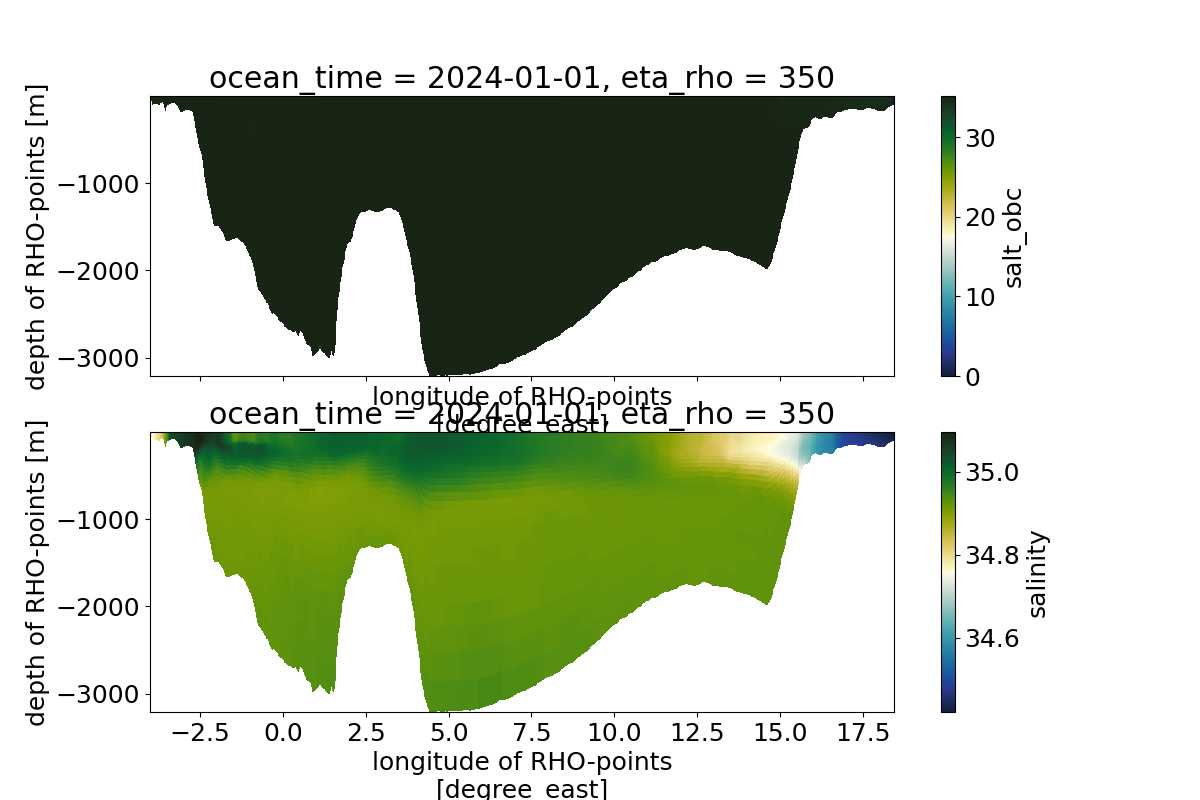

In [ ]:
fig2, aks = plt.subplots(2,1,figsize=(12, 8), sharex=True, sharey=True)

salt_zlayer = salt_west0.where(~salt_west0.isnull().compute(), drop=True)

# Turns out we need to remove the nans in the vertical coordinate
mask = (salt_west0.cf['vertical'].isnull())
salt_zlayer_clean = salt_west0.where(~mask, drop=True)

salt_zlayer_clean.cf.plot(ax=aks[0], x='longitude', y='vertical', cmap=cmo.delta)

salt = ds0.salt.cf.isel(Y=350, T=0)
sz = salt.where(~salt.isnull().compute(), drop=True)
sz.cf.plot(ax=aks[1], x='longitude', y='vertical', cmap=cmo.delta)

### Difference plot

In [6]:
def get_boundary_var_diff(var_0, var_1):

    # Align the vertical coordinates (dont know why they are different, probably due to xroms processing)
    # you can see the disalignment by
    # np.allclose(var_0.cf['vertical'], var_1.cf['vertical']) # == False
    var_1 = var_1.assign_coords(vertical=var_0.cf['vertical'])

    diff_boundary = var_0 - var_1

    # Remove values where the vertical coordinate is nan
    # and the last index (which is not used in xroms)
    mask = (diff_boundary.cf['vertical'].isnull())
    diff_boundary = diff_boundary.where(~mask, drop=True)[:,:-1]

    # Remove values under seafloor
    diff_z = diff_boundary.where(~diff_boundary.isnull().compute(), drop=True)

    vmin = np.nanmin(diff_boundary.values)
    vmax = np.nanmax(diff_boundary.values)
    #print(f'diff var_obc: min= {vmin}, max= {vmax}')
    #vminmax = max(abs(vmin),vmax)

    return diff_z, vmin, vmax

### Diff salt_obc each month

min_global: -0.01564788818359375, max_global: 0.00341033935546875
Hello, I saved the figure with TwoSlopeNorm norm


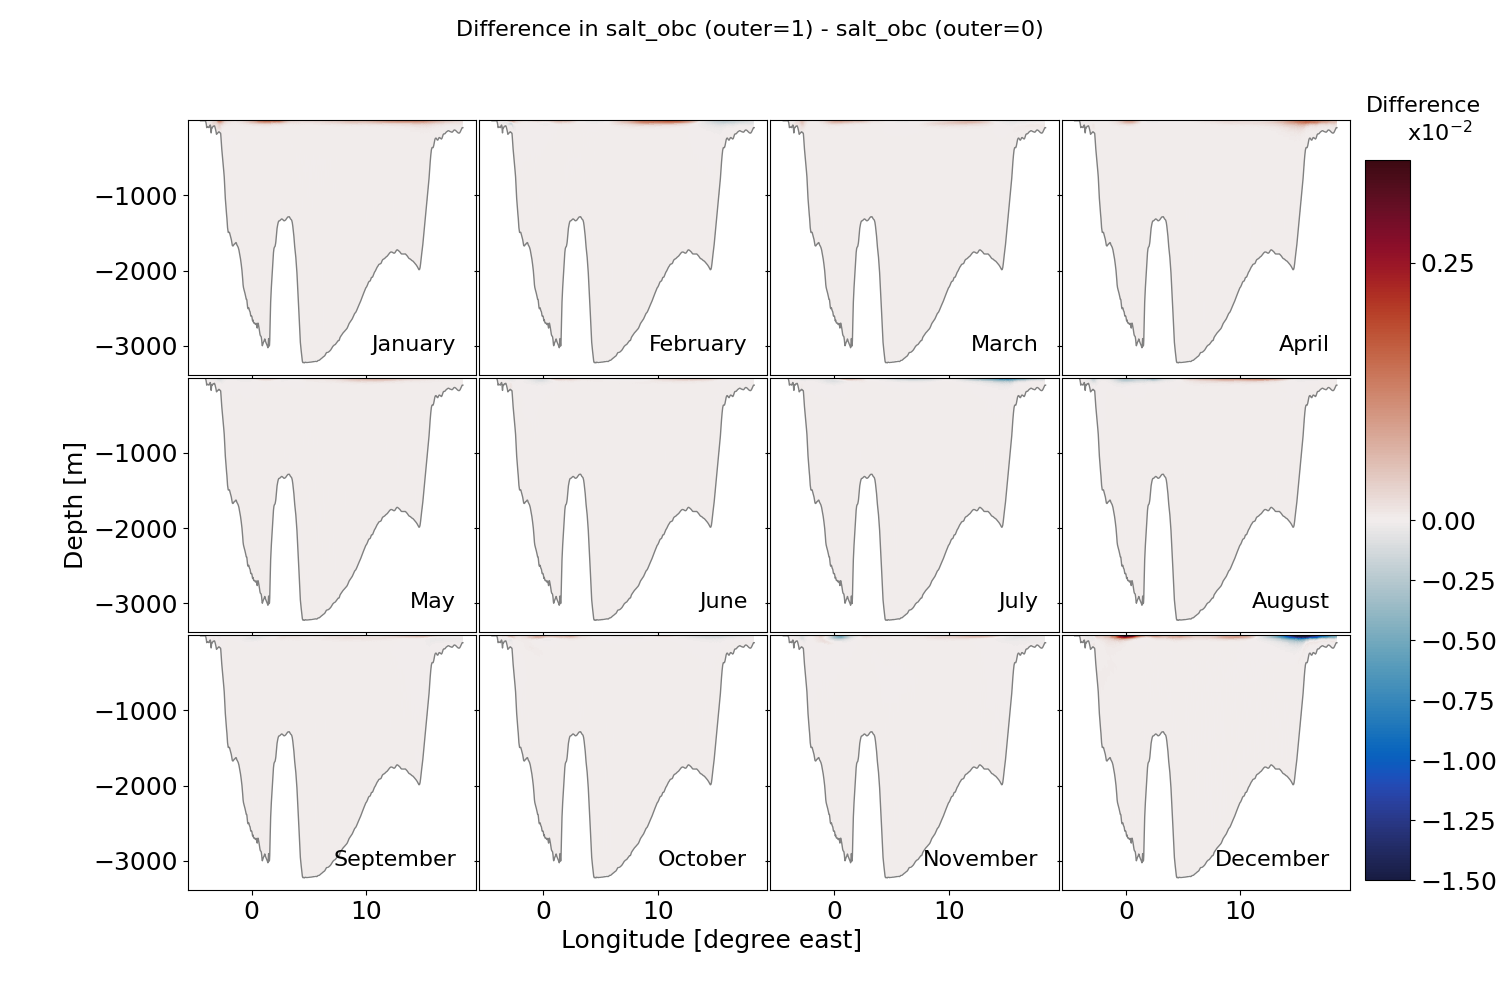

In [28]:
import matplotlib.ticker as ticker

#min_global: -0.01564788818359375, max_global: 0.00341033935546875
#norm = mcolors.SymLogNorm(linthresh=1e-4, linscale=1, vmin=-0.002, vmax=0.0005, base=10)
norm = mcolors.TwoSlopeNorm(vmin=-0.015, vcenter=0, vmax=0.0035)
#norm = mcolors.SymLogNorm(linthresh=1e-4, linscale=1, vmin=-0.015, vmax=0.0035, base=10)
kwargs={'norm': norm, 'cmap':cmo.balance,'add_colorbar': False} 

# seafloor depth
h = ds0.h.cf.isel(Y=350, T=0)

# Plot each month in a 3x4 grid
fig, axs = plt.subplots(3, 4, figsize=(15, 10),sharex=True,sharey=True)
axs = axs.flatten()

quadmesh = None
min_global = 99; max_global = -99
for i in range(12):
    ax = axs[i]
    
    salt_west0 = ds0.salt_obc.cf.isel(Y=350, T=i) 
    salt_west1 = ds1.salt_obc.cf.isel(Y=350, T=i)
    diff_z,smin,smax = get_boundary_var_diff(salt_west0, salt_west1)
    min_global = min(min_global, smin)
    max_global = max(smax, max_global)

    quadmesh = diff_z.cf.plot(ax=ax, x='longitude', y='vertical',**kwargs)
    
    # plot a line of the seafloor (which is 2D)
    ax.plot(h.cf['longitude'], -h, color='gray', linewidth=1, label='h')

    # Formatting
    month_str = salt_west0.ocean_time.dt.strftime('%B').values  # Get the name of the month
    month_patch = mpatches.Patch(color='none', label=month_str)
    ax.legend(handles=[month_patch], loc='lower right', fontsize=16, frameon=False)
    ax.set_title("")

    if i in [4]: #[0,4,8]: 
        ax.set_ylabel("Depth [m]")
    else: 
        ax.set_ylabel("")
    if i in [9]:#[8,9,10,11]: 
        ax.set_xlabel(f"                      Longitude [degree east]")
    else:
        ax.set_xlabel("")

print(f'min_global: {min_global}, max_global: {max_global}')

fig.suptitle('Difference in salt_obc (outer=1) - salt_obc (outer=0)', fontsize=16)

plt.subplots_adjust(wspace=0.01, hspace=0.01)

# Add a colorbar axis: [left, bottom, width, height] in figure coordinates (0-1)
cax = fig.add_axes([0.91, 0.12, 0.03, 0.72])  # adjust as needed

cbar = fig.colorbar(
    quadmesh, 
    cax=cax,
    orientation='vertical', 
    pad=0.01,
    )
#cbar.set_label('Difference', labelpad=10, fontsize=16, loc='top', rotation=0)
cax.text(
    0.01, 1.02,                # x, y position in axis coordinates (centered above)
    'Difference\n      x$10^{-2}$',
    ha='left', va='bottom', # Horizontal and vertical alignment
    fontsize=16, #fontweight='bold', 
    transform=cax.transAxes
)

# figname depends on the norm used
if isinstance(norm, mcolors.TwoSlopeNorm):
    # Force scientific notation on colorbar labels
    cbar.formatter = ticker.ScalarFormatter(useMathText=True)
    cbar.formatter.set_scientific(True)
    cbar.formatter.set_powerlimits((0, 0))

    # Access the offset text object
    offset_text = cbar.ax.yaxis.get_offset_text()
    offset_text.set_visible(False)

    cbar.update_ticks()

    fig.savefig('salt_obc_diff_outer1-outer0_lin.png')
    print("Hello, I saved the figure with TwoSlopeNorm norm")
elif isinstance(norm, mcolors.SymLogNorm):
    fig.savefig('salt_obc_diff_outer1-outer0.png')
else:
    print('Unknown norm type, not saving figure!')

## Standard deviation of the difference

In [47]:
diff_z.shape
std_diff = np.std(diff_z,axis=0)
std_diff

<xarray.DataArray 'temp_obc' (xi_rho: 858)> Size: 7kB
array([0.00000000e+00, 1.18485764e-04, 1.21911527e-04, 1.24105785e-04,
       1.24311441e-04, 1.22277536e-04, 1.19193165e-04, 1.18045954e-04,
       1.17382070e-04, 1.16480673e-04, 1.15179374e-04, 1.13392807e-04,
       1.11639007e-04, 1.09999588e-04, 1.08460485e-04, 1.06767685e-04,
       1.05049043e-04, 1.03599203e-04, 1.02066189e-04, 1.00795937e-04,
       9.96086953e-05, 9.85003493e-05, 9.77706564e-05, 9.71291380e-05,
       9.65733657e-05, 9.61718965e-05, 9.59354039e-05, 9.53904165e-05,
       9.49374929e-05, 9.48168117e-05, 9.46218977e-05, 9.39833399e-05,
       9.30183941e-05, 9.19579674e-05, 9.20537595e-05, 9.33175924e-05,
       9.71293583e-05, 1.00901919e-04, 1.03434190e-04, 1.05513789e-04,
       1.08258886e-04, 1.11273273e-04, 1.12457534e-04, 1.12073928e-04,
       1.16140496e-04, 1.20969625e-04, 1.24760949e-04, 1.28408910e-04,
       1.31751593e-04, 1.33837267e-04, 1.35518453e-04, 1.38819341e-04,
       1.39971045e-04, 1.40598991e-04, 1.42859082e-04, 1.46700311e-04,
       1.51098876e-04, 1.55616991e-04, 1.60108248e-04, 1.63003772e-04,
       1.62804132e-04, 1.61859641e-04, 1.63894298e-04, 1.69431343e-04,
       1.78304824e-04, 1.90623348e-04, 2.05220546e-04, 2.17455476e-04,
       2.28355543e-04, 2.40968151e-04, 2.53495419e-04, 2.65237613e-04,
       2.76871202e-04, 2.89939951e-04, 3.05381565e-04, 3.18835706e-04,
       3.25914526e-04, 3.28550444e-04, 3.32351198e-04, 3.36763209e-04,
...
       6.47277956e-04, 6.65785906e-04, 6.83556315e-04, 7.00927143e-04,
       7.17603917e-04, 7.34493486e-04, 7.52720824e-04, 7.73141449e-04,
       7.96487925e-04, 8.21999359e-04, 8.47412138e-04, 8.72432140e-04,
       8.99129318e-04, 9.27245739e-04, 9.55781690e-04, 9.83812558e-04,
       1.01052440e-03, 1.03745899e-03, 1.06478944e-03, 1.09305992e-03,
       1.12233768e-03, 1.15334320e-03, 1.18435809e-03, 1.21676746e-03,
       1.25491535e-03, 1.30064593e-03, 1.35908651e-03, 1.41074814e-03,
       1.42898477e-03, 1.42959530e-03, 1.43108896e-03, 1.44229635e-03,
       1.45877186e-03, 1.46893882e-03, 1.46983214e-03, 1.46357230e-03,
       1.45100883e-03, 1.43367304e-03, 1.41531222e-03, 1.39944191e-03,
       1.38801311e-03, 1.37654790e-03, 1.36332941e-03, 1.35302776e-03,
       1.34500064e-03, 1.34187348e-03, 1.33951134e-03, 1.33078236e-03,
       1.31917568e-03, 1.30643200e-03, 1.28850471e-03, 1.26822594e-03,
       1.24638088e-03, 1.23041687e-03, 1.21497771e-03, 1.20179272e-03,
       1.19338323e-03, 1.18666470e-03, 1.17582336e-03, 1.16542986e-03,
       1.15979851e-03, 1.15927744e-03, 1.15635985e-03, 1.15122346e-03,
       1.14625773e-03, 1.14474255e-03, 1.14960893e-03, 1.15312259e-03,
       1.15486808e-03, 1.15721422e-03, 1.15426861e-03, 1.14846916e-03,
       1.14212727e-03, 1.13388122e-03, 1.12312319e-03, 1.11278398e-03,
       1.09824132e-03, 1.08230080e-03])
Coordinates:
    ocean_time  datetime64[ns] 8B 2024-12-01
    lat_rho     (xi_rho) float64 7kB 58.58 58.6 58.62 ... 75.73 75.75 75.77
    lon_rho     (xi_rho) float64 7kB -4.001 -3.99 -3.979 ... 18.24 18.3 18.35
  * xi_rho      (xi_rho) int64 7kB 42 43 44 45 46 47 ... 894 895 896 897 898 899
    eta_rho     int64 8B 350

Text(0.5, 1.0, 'Standard Deviation of Model Difference (Western Boundary)')

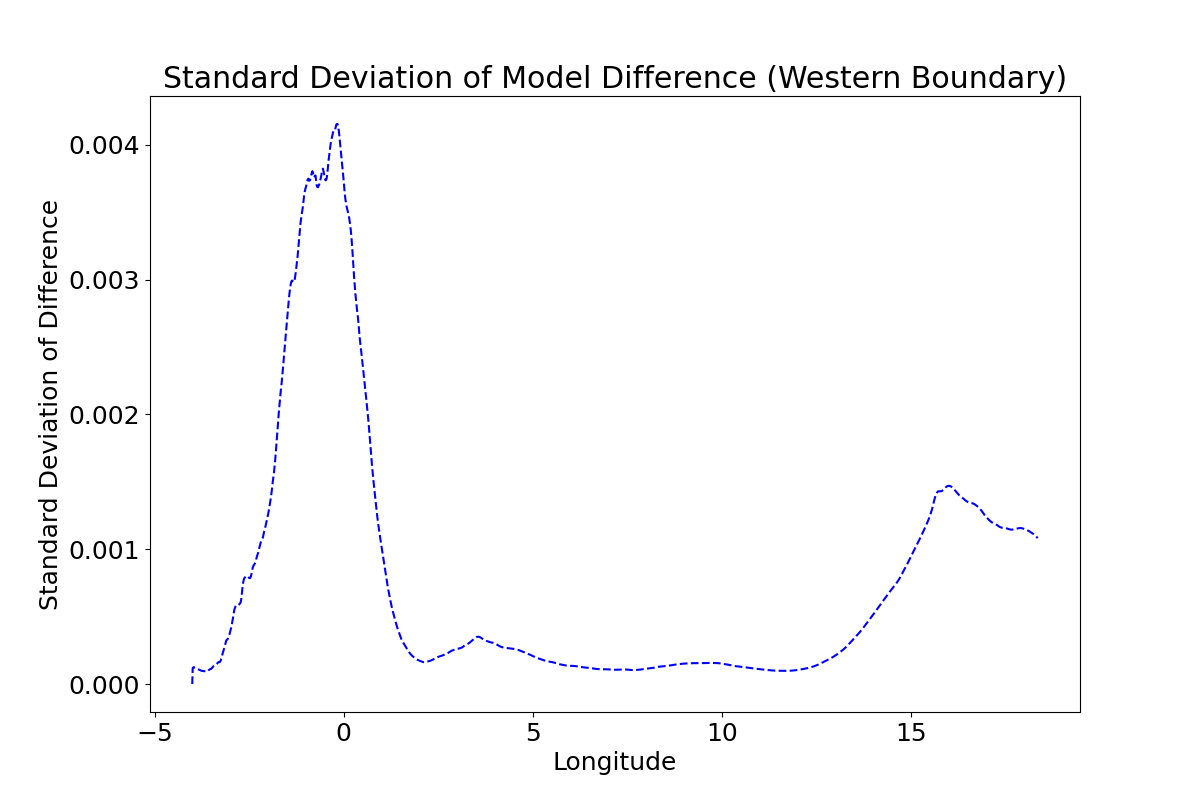

In [49]:
# Plot
fig, ak1 = plt.subplots(1)

longitude = diff_z.cf['longitude'].values

ak1.plot(longitude, std_diff, linestyle='--', color='b')
ak1.set_xlabel('Longitude')
ak1.set_ylabel('Standard Deviation of Difference')
ak1.set_title('Standard Deviation of Model Difference (Western Boundary)')


### Yearly difference salt

In [24]:
# calculate the yearly mean difference
salt_west0_yearly = ds0.salt_obc.cf.isel(Y=350).mean(dim='ocean_time')
salt_west1_yearly = ds1.salt_obc.cf.isel(Y=350).mean(dim='ocean_time')

salt_west0_yearly = salt_west0_yearly.assign_coords(z_rho=salt_west0['z_rho'])
salt_west1_yearly = salt_west1_yearly.assign_coords(z_rho=salt_west1['z_rho'])

diff_z_yearly, smin_yearly, smax_yearly = get_boundary_var_diff(salt_west0_yearly, salt_west1_yearly)

ymin = diff_z_yearly.cf['vertical'].min().values
ymax = diff_z_yearly.cf['vertical'].max().values
print(f'Yearly mean diff: min= {smin_yearly}, max= {smax_yearly}')

Yearly mean diff: min= -0.00197188059489406, max= 0.00046539306640625


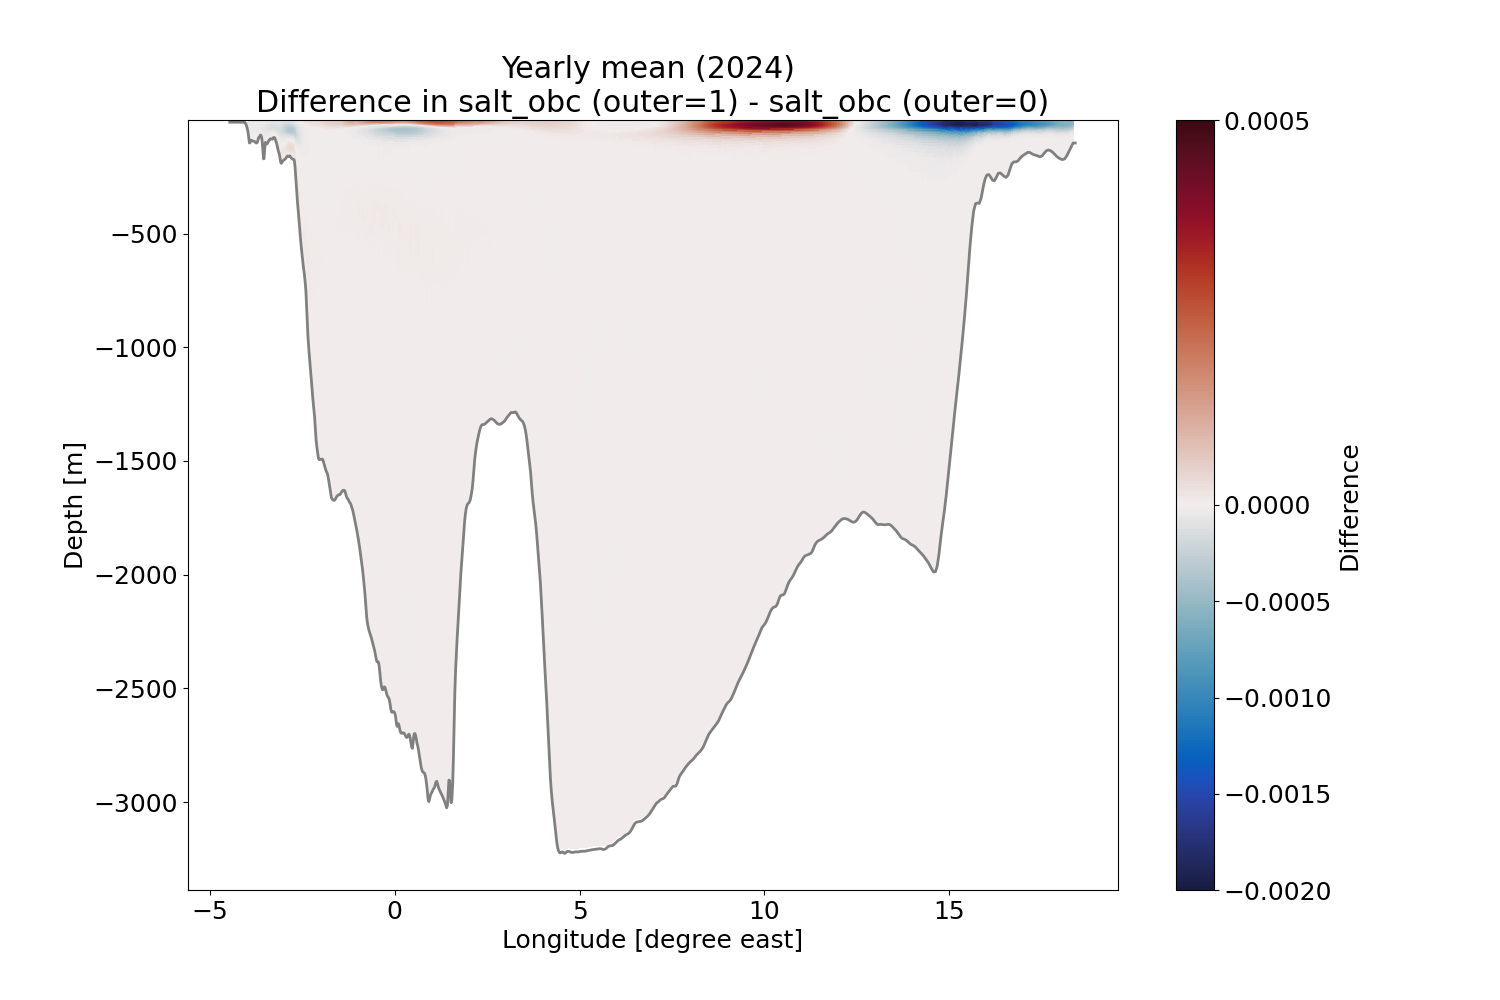

In [30]:
# Using same norm as for the monthly plots for salt (larger range)
norm = mcolors.TwoSlopeNorm(vmin=-0.002, vcenter=0, vmax=0.0005)
#norm = mcolors.SymLogNorm(linthresh=1e-4, linscale=1, vmin=-0.015, vmax=0.0035, base=10)
kwargs={'norm': norm, 'cmap':cmo.balance,'cbar_kwargs': {'label': 'Difference'}} 

# Plot the yearly mean difference
fig_yr, ax_yr = plt.subplots(figsize=(15, 10))
diff_z_yearly.cf.plot(ax=ax_yr, x='longitude', y='vertical', **kwargs)

# plot a line of the seafloor (which is 2D)
ax_yr.plot(h.cf['longitude'], -h, color='gray', linewidth=2, label='h')

ax_yr.set_title("Yearly mean (2024) \nDifference in salt_obc (outer=1) - salt_obc (outer=0)")
ax_yr.set_ylabel("Depth [m]")
ax_yr.set_xlabel(f"Longitude [degree east]")

# figname depends on the norm used
if isinstance(norm, mcolors.TwoSlopeNorm):
    # TODO may add scientific notation on colorbar labels as fig above (se that code block)

    fig_yr.savefig('salt_obc_diff_yearly_outer1-outer0_lin.png')
elif isinstance(norm, mcolors.SymLogNorm):
    fig_yr.savefig('salt_obc_diff_yearly_outer1-outer0.png')
else:
    print('Unknown norm type, not saving figure!')

### Diff temperature

min_global: -0.031853675842285156, max_global: 0.0251617431640625
Hello, I saved the figure with TwoSlopeNorm norm


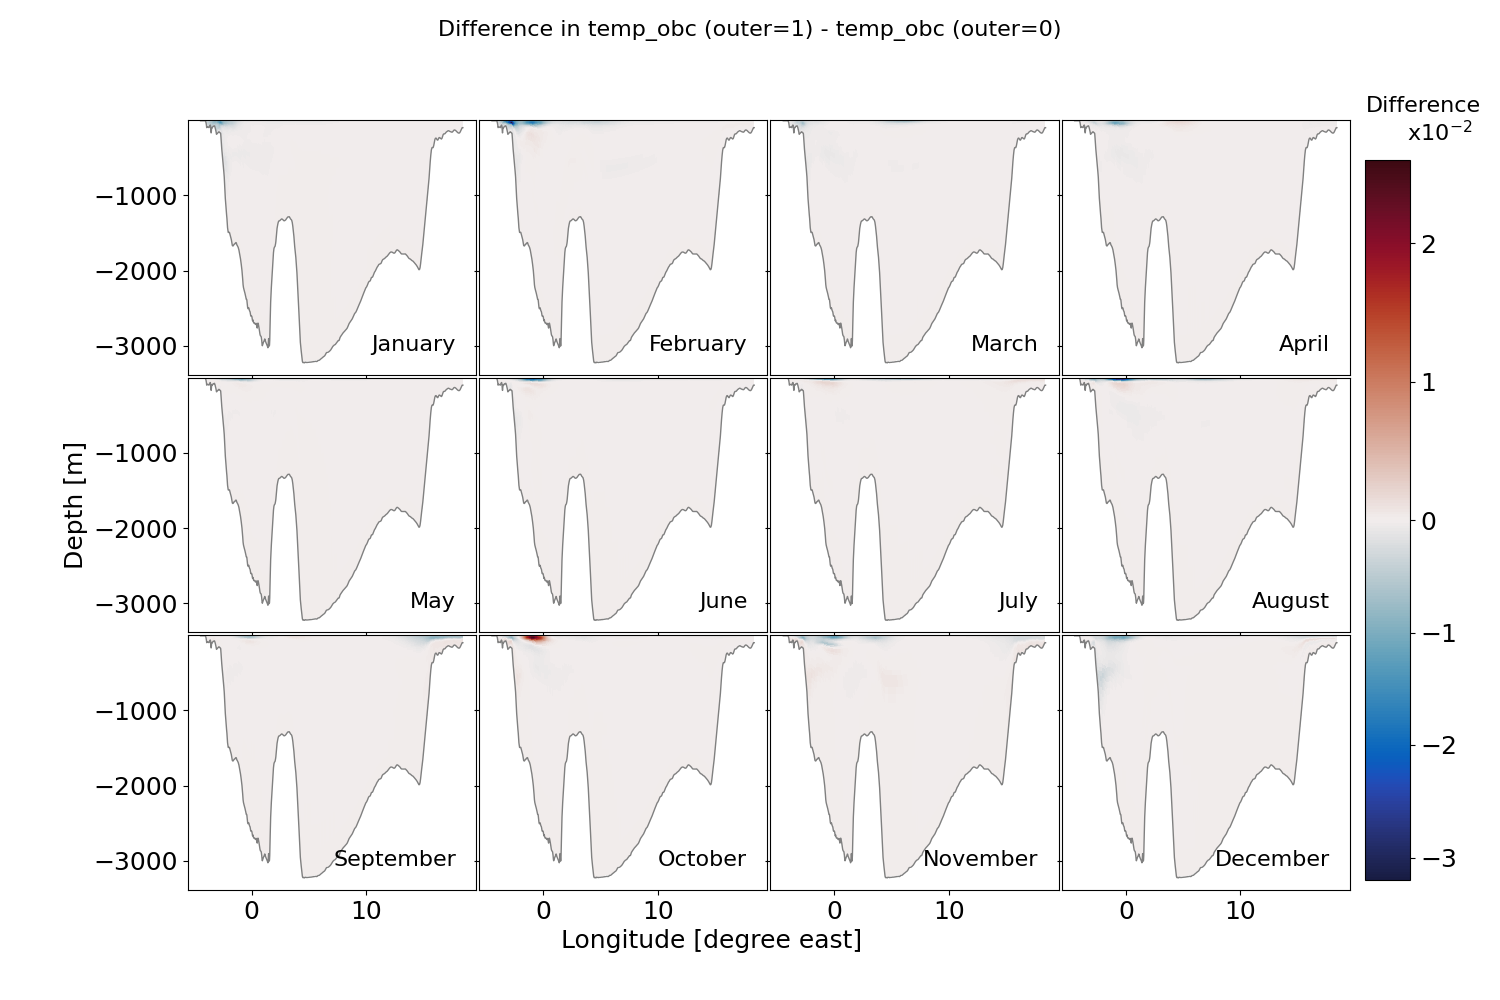

In [33]:
#min_global: -0.031853675842285156, max_global: 0.0251617431640625
norm = mcolors.TwoSlopeNorm(vmin=-0.032, vcenter=0, vmax=0.026)
#norm = mcolors.SymLogNorm(linthresh=1e-4, linscale=1, vmin=-0.002, vmax=0.0005, base=10)
#norm = mcolors.SymLogNorm(linthresh=1e-4, linscale=1, vmin=-0.032, vmax=0.026, base=10)
kwargs={'norm': norm, 'cmap':cmo.balance,'add_colorbar': False} 

# seafloor depth
h = ds0.h.cf.isel(Y=350, T=0)

# Plot each month in a 3x4 grid
fig, axs = plt.subplots(3, 4, figsize=(15, 10),sharex=True,sharey=True)
axs = axs.flatten()

quadmesh = None
min_global = 99; max_global = -99
for i in range(12):
    ax = axs[i]
    
    temp_west0 = ds0.temp_obc.cf.isel(Y=350, T=i) 
    temp_west1 = ds1.temp_obc.cf.isel(Y=350, T=i)
    diff_z,smin,smax = get_boundary_var_diff(temp_west0, temp_west1)
    min_global = min(min_global, smin)
    max_global = max(smax, max_global)

    quadmesh = diff_z.cf.plot(ax=ax, x='longitude', y='vertical',**kwargs)
    
    # plot a line of the seafloor (which is 2D)
    ax.plot(h.cf['longitude'], -h, color='gray', linewidth=1, label='h')

    # Formatting
    month_str = temp_west0.ocean_time.dt.strftime('%B').values  # Get the name of the month
    month_patch = mpatches.Patch(color='none', label=month_str)
    ax.legend(handles=[month_patch], loc='lower right', fontsize=16, frameon=False)
    ax.set_title("")

    if i in [4]: #[0,4,8]: 
        ax.set_ylabel("Depth [m]")
    else: 
        ax.set_ylabel("")
    if i in [9]:#[8,9,10,11]: 
        ax.set_xlabel(f"                      Longitude [degree east]")
    else:
        ax.set_xlabel("")

print(f'min_global: {min_global}, max_global: {max_global}')

fig.suptitle('Difference in temp_obc (outer=1) - temp_obc (outer=0)', fontsize=16)

plt.subplots_adjust(wspace=0.01, hspace=0.01)

# Add a colorbar axis: [left, bottom, width, height] in figure coordinates (0-1)
cax = fig.add_axes([0.91, 0.12, 0.03, 0.72])  # adjust as needed

cbar = fig.colorbar(
    quadmesh, 
    cax=cax,
    orientation='vertical', 
    pad=0.01,
    )
#cbar.set_label('Difference', labelpad=10, fontsize=16, loc='top', rotation=0)
cax.text(
    0.01, 1.02,                # x, y position in axis coordinates (centered above)
    'Difference\n      x$10^{-2}$',             # Your label
    ha='left', va='bottom', # Horizontal and vertical alignment
    fontsize=16, #fontweight='bold', 
    transform=cax.transAxes
)


# figname depends on the norm used
if isinstance(norm, mcolors.TwoSlopeNorm):
    # Force scientific notation on colorbar labels
    cbar.formatter = ticker.ScalarFormatter(useMathText=True)
    cbar.formatter.set_scientific(True)
    cbar.formatter.set_powerlimits((0, 0))

    # Access the offset text object
    offset_text = cbar.ax.yaxis.get_offset_text()
    offset_text.set_visible(False)

    cbar.update_ticks()

    fig.savefig('temp_obc_diff_outer1-outer0_lin.png')
    print("Hello, I saved the figure with TwoSlopeNorm norm")
elif isinstance(norm, mcolors.SymLogNorm):
    fig.savefig('temp_obc_diff_outer1-outer0.png')
else:
    print('Unknown norm type, not saving figure!')

### Yearly diff temp

In [34]:
# calculate the yearly mean difference
temp_west0_yearly = ds0.temp_obc.cf.isel(Y=350).mean(dim='ocean_time')
temp_west1_yearly = ds1.temp_obc.cf.isel(Y=350).mean(dim='ocean_time')

temp_west0_yearly = temp_west0_yearly.assign_coords(z_rho=temp_west0['z_rho'])
temp_west1_yearly = temp_west1_yearly.assign_coords(z_rho=temp_west1['z_rho'])

diff_temp_z_yearly, smin_yearly, smax_yearly = get_boundary_var_diff(temp_west0_yearly, temp_west1_yearly)

ymin = diff_temp_z_yearly.cf['vertical'].min().values
ymax = diff_temp_z_yearly.cf['vertical'].max().values
print(f'Yearly mean diff: min= {smin_yearly}, max= {smax_yearly}')

Yearly mean diff: min= -0.008490045865376494, max= 0.0002504587173461914


Hello, I saved the figure with TwoSlopeNorm norm


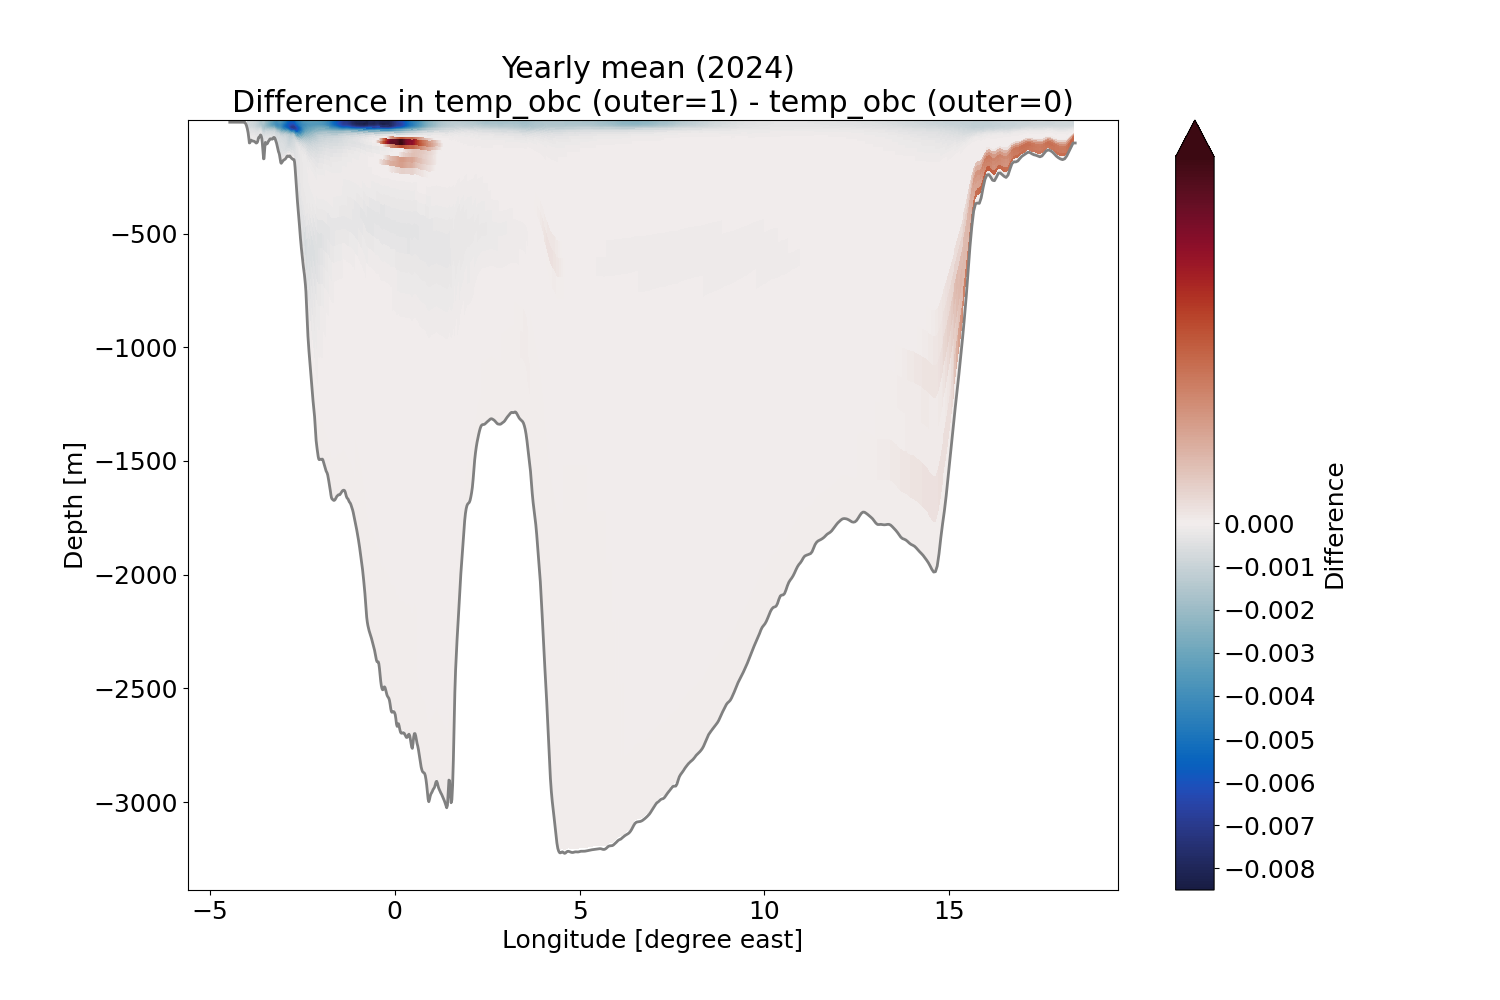

In [37]:
# Using the same norm as for monthly temp
norm = mcolors.TwoSlopeNorm(vmin=-0.0085, vcenter=0, vmax=0.00025)
#norm = mcolors.SymLogNorm(linthresh=1e-4, linscale=1, vmin=-0.032, vmax=0.026, base=10)
kwargs={'norm': norm, 'cmap':cmo.balance,'cbar_kwargs': {'label': 'Difference'}} 

# Plot the yearly mean difference
fig_yr, ax_yr = plt.subplots(figsize=(15, 10))
diff_temp_z_yearly.cf.plot(ax=ax_yr, x='longitude', y='vertical', **kwargs)

# plot a line of the seafloor (which is 2D)
ax_yr.plot(h.cf['longitude'], -h, color='gray', linewidth=2, label='h')

ax_yr.set_title("Yearly mean (2024) \nDifference in temp_obc (outer=1) - temp_obc (outer=0)")
ax_yr.set_ylabel("Depth [m]")
ax_yr.set_xlabel(f"Longitude [degree east]")

# figname depends on the norm used
if isinstance(norm, mcolors.TwoSlopeNorm):
    fig_yr.savefig('temp_obc_diff_yearly_outer1-outer0_lin.png')
    print("Hello, I saved the figure with TwoSlopeNorm norm")
elif isinstance(norm, mcolors.SymLogNorm):
    fig_yr.savefig('temp_obc_diff_yearly_outer1-outer0.png')
else:
    print('Unknown norm type, not saving figure!')

### Plotting one month diff

In [ ]:
salt_west0 = ds0.salt_obc.cf.isel(Y=350, T=0) #TODO: loop over T, T=0 is January
salt_west1 = ds1.salt_obc.cf.isel(Y=350, T=0)

diff_z,smin,smax = get_boundary_var_diff(salt_west0, salt_west1)

In [ ]:
#from matplotlib import colors
#norm = colors.Normalize(vmin=dmin, vmax=dmax)
#kwargs={'norm':norm, 'cmap':'coolwarm'}
kwargs={'vmin':smin, 'vmax':smax, 'cmap':'Reds','cbar_kwargs': {'label': 'Difference'}}

fig, axs = plt.subplots(1)

diff_z.cf.plot(ax=axs, x='longitude', y='vertical',**kwargs)

# plot a line of the seafloor (which is 2D)
h = ds0.h.cf.isel(Y=350, T=0)
axs.plot(h.cf['longitude'], -h, color='gray', linewidth=1, label='h')

axs.set_title('2024: salt_obc(outer=1) - salt_obc(outer=0)')
axs.set_ylabel("Depth [m]")
axs.set_xlabel("Longitude [degree east]")

# Animation?
TODO: add this to utils.py

In [ ]:
from matplotlib.animation import FuncAnimation

In [ ]:
kwargs={'vmin':dmin, 'vmax':dmax, 'cmap':'coolwarm'}

# Function to update the plot for each frame
def update(frame):
    ax.clear()
    im = ax.pcolor(diff_salt_obc[frame,:,:], **kwargs)
    ax.set_title(f"Time step: {frame}")
    return im,

# Set up the figure and axis
fig, ax = plt.subplots()

# Create the animation object
anim = FuncAnimation(fig, update, frames=ntime, blit=True)

# Display the colorbar
fig.colorbar(ax.pcolor(diff_salt_obc[0,:,:], **kwargs), ax=ax)

# Show the animation
#plt.show()